<a href="https://colab.research.google.com/github/Taheri1400/deep-learning-projects/blob/main/studying.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 dir=rtl align=center style="direction: rtl;line-height:200%;font-family:vazir;color:#0099cc">
<font dir=rtl face="vazir" color="#0099cc">
چقدر درس بخونم؟
</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین می‌خواهیم با استفاده از <b>نزول گرادیان</b> یک مدل خطی چندمتغیره را آموزش دهیم و کاهش خطا را در طول آموزش مشاهده کنیم.  
مجموعه داده ما شامل اطلاعاتی از عوامل مختلف مؤثر بر نمره‌ی امتحان دانشجویان است؛ مانند ساعت مطالعه، نرخ حضور، میزان خواب و غیره.  
هدف این است که بتوانیم براساس این ویژگی‌ها، نمره‌ی دانشجو را پیش‌بینی کنیم.
</font>
</p>

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مجموعه‌داده
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
جدول زیر نمونه‌ای از داده‌های ما را نشان می‌دهد:
</font>
</p>

<center>
<div dir=rtl style="direction: rtl;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

| <b>ساعت مطالعه</b> | <b>نرخ حضور</b> | <b>ساعت خواب</b> | <b>تعداد تمرین‌ها</b> | <b>ساعت حواس‌پرتی</b> | <b>سختی درس</b> | <b>نمره امتحان</b> |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 6.18 | 0.85 | 8.11 | 150 | 1.24 | 1 | 97.50 |
| 2.47 | 0.78 | 6.02 | 85  | 3.45 | 2 | 75.33 |
| 7.56 | 0.92 | 7.48 | 180 | 0.50 | 1 | 99.12 |
| 4.35 | 0.66 | 5.21 | 40  | 4.00 | 3 | 65.27 |
| 5.12 | 0.88 | 7.15 | 120 | 2.15 | 2 | 89.40 |

</font>
</div>
</center>



<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بارگذاری کتابخانه‌ها و مجموعه‌داده
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا، شما باید کتابخانه‌های مورد نیاز را برای پردازش داده (pandas) و محاسبات عددی (numpy) بارگذاری کنید و سپس فایل مجموعه‌داده را که شامل ویژگی‌های مختلف دانشجویان است، وارد محیط کاری خود کنید.
</font>
</p>





In [1]:
!pip install keras --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2


In [2]:
import numpy as np
import pandas as pd

In [3]:

df = pd.read_csv('data.csv')
df

,hours_studied,attendance_rate,sleep_hours,practice_questions,distraction_hours,course_difficulty,exam_score
0,6.30,0.89,5.51,176,1.21,1,100.00
1,3.79,0.99,8.59,95,1.61,2,88.01
2,6.94,0.75,7.91,197,0.78,2,100.00
3,5.73,0.57,4.55,153,4.37,1,80.98
4,1.21,0.51,8.99,130,1.42,1,68.67
...,...,...,...,...,...,...,...
195,1.84,0.73,5.39,118,4.41,1,58.96
196,5.00,0.91,7.52,124,1.39,2,85.46
197,7.06,0.65,7.17,131,1.01,3,90.77
198,1.97,0.73,8.91,5,0.93,1,63.51


<h2  dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
آماده‌سازی ویژگی‌ها و متغیر هدف
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش، باید ستون exam_score را به عنوان <b>متغیر هدف</b> (y) در نظر گرفته ‌شود و بقیه ستون‌ها به عنوان <b>ویژگی‌ها</b> (X) استفاده شوند. سپس این مقادیر را به نوع داده عددی <b>float</b> تبدیل کنید و ابعاد مجموعه داده را به‌دست آورید. بهتر است که  feature_cols را در اینجا مقداردهی کنید.
</font>
</p>


In [4]:
df.columns


Index(['hours_studied', 'attendance_rate', 'sleep_hours', 'practice_questions',
       'distraction_hours', 'course_difficulty', 'exam_score'],
      dtype='object')

In [5]:
target_col =  'exam_score'
feature_cols =  ['hours_studied', 'attendance_rate', 'sleep_hours', 'practice_questions',
       'distraction_hours', 'course_difficulty']
X = df[feature_cols].astype(float).values
y = df[target_col].astype(float).values
n, d = X.shape

In [6]:
X.shape

(200, 6)

<h2 style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
استانداردسازی ویژگی‌ها
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
برای بهبود عملکرد الگوریتم نزول گرادیان و جلوگیری از تأثیر مقیاس‌های متفاوت ویژگی‌ها، باید داده‌ها را استانداردسازی کنید.  
استانداردسازی باعث می‌شود میانگین هر ویژگی برابر صفر و انحراف معیار آن برابر یک شود.
</font>
</p>



In [7]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

In [8]:
X_scaler.mean(axis=0)

array([ 1.50990331e-16,  6.57252031e-16, -4.04121181e-16, -5.32907052e-17,
       -9.76996262e-17, -4.88498131e-17])

<h2 dir="rtl" style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
مقداردهی اولیه پارامترها (ثابت)
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله باید پارامترهای اولیه مدل خطی خود را <b>دقیقاً با مقادیر مشخص‌شده</b> مقداردهی کنیم. این پارامترها شامل وزن‌ها (<b>w</b>)، بایاس (<b>b</b>)، نرخ یادگیری (<b>alpha</b>) و تعداد تکرارهای آموزش (<b>epochs</b>) هستند. همچنین برای تولید اعداد تصادفی ثابت و قابل بازتولید، باید از یک بذر تصادفی ثابت استفاده کنیم. لطفا برای ارسال جواب نهایی از همین پارامترها استفاده کنید، اما خودتان می‌توانید با تغییر این پارامترها تاثیر آن را مشاهده کنید.
</font>
</p>

In [9]:
np.random.seed(42)
w = np.random.randn(d)  # weights
b = 0.0                 # bias
alpha = 0.05            # learning rate
epochs = 50
losses = []

<h2 dir="rtl" style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
حلقه آموزش با استفاده از نزول گرادیان
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله، باید الگوریتم نزول گرادیان را به صورت دستی پیاده‌سازی کنید تا مدل خطی شما آموزش ببیند.  
این فرآیند شامل پیش‌بینی خروجی‌ها، محاسبه خطا، محاسبه گرادیان‌ها و به‌روزرسانی وزن‌ها و بایاس است.
</font>
</p>

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
دستورالعمل
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
۱. یک حلقه <b>for</b> به اندازه تعداد تکرارها (<b>epochs</b>) ایجاد کنید.<br>
۲. در هر تکرار:
   <br>
   &nbsp;&nbsp;الف) خروجی پیش‌بینی‌شده (<b>y_pred</b>) را برای همه نمونه‌ها محاسبه کنید.  <br>
   &nbsp;&nbsp;ب) خطا (<b>err</b>) را با تفریق پیش‌بینی‌ها از مقادیر واقعی محاسبه کنید. <br>
   &nbsp;&nbsp;پ) مقدار میانگین مربعات خطا (<b>loss</b>) را حساب کرده و در لیست <b>losses</b> ذخیره کنید.<br>
   &nbsp;&nbsp;ت) گرادیان وزن‌ها (<b>dw</b>) را برای هر ویژگی محاسبه کنید.  <br>
   &nbsp;&nbsp;ث) گرادیان بایاس (<b>db</b>) را محاسبه کنید.<br>
   &nbsp;&nbsp;ج) وزن‌ها و بایاس را با استفاده از نرخ یادگیری (<b>alpha</b>) به‌روزرسانی کنید.<br>
۳. برای بررسی روند آموزش، در ابتدای آموزش و هر ۱۰ تکرار یکبار، شماره تکرار و مقدار خطا را چاپ کنید.
</font>
</p>


In [10]:
for epoch in range(epochs):
    y_pred=X_scaler @ w +b
    err=y-y_pred
    loss=np.mean(err**2)
    losses.append(loss)
    dw = -(2 / n) * (X_scaler.T @ err)
    db = -(2 / n) * np.sum(err)
    w=w-alpha*dw
    b=b-alpha*db
    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss:.4f}")


Epoch 1: Loss = 6109.5882
Epoch 10: Loss = 931.0657
Epoch 20: Loss = 128.6551
Epoch 30: Loss = 30.8153
Epoch 40: Loss = 18.8205
Epoch 50: Loss = 17.3388


In [11]:
print("Final train MSE:", losses[-1])

Final train MSE: 17.338753228317433


<h2 dir="rtl" style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
برگرداندن وزن‌ها به مقیاس اصلی داده‌ها
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
پس از آموزش مدل با داده‌های استانداردشده، وزن‌ها و بایاس به مقیاس استاندارد وابسته‌اند. برای تفسیر بهتر نتایج، لازم است این مقادیر را به مقیاس اصلی داده‌ها برگردانیم تا بتوانیم ارتباط هر ویژگی با متغیر هدف را به شکل واقعی مشاهده کنیم.
</font>
</p>

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
دستورالعمل
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
۱. وزن‌های استانداردشده را با تقسیم هر وزن بر مقدار <b>scale_</b> مربوط به همان ویژگی از شیء <b>scaler</b> به مقیاس اصلی برگردانید.<br>
۲. بایاس را با استفاده از رابطه:
   <br>
   <code>b_orig = b - np.sum((scaler.mean_ / scaler.scale_) * w)</code>
   <br>
   به مقیاس اصلی تبدیل کنید.<br>
۳. همه‌ی وزن‌ها و بایاس تبدیل‌شده را همراه با نام ویژگی‌ها چاپ کنید.
</font>
</p>


In [12]:
w_orig = w / scaler.scale_

b_orig = b - np.sum((scaler.mean_ / scaler.scale_) * w)

print("\n=== Weights on ORIGINAL scale ===")
for name, wi in zip(feature_cols, w_orig):
    print(f"{name:20s}: {wi: .4f}")
print(f"{'bias':20s}: {b_orig: .4f}")


=== Weights on ORIGINAL scale ===
hours_studied       :  5.9129
attendance_rate     :  17.6557
sleep_hours         :  1.9479
practice_questions  :  0.0916
distraction_hours   : -2.9500
course_difficulty   : -4.6275
bias                :  31.7305


<h2 dir="rtl" style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
رسم نمودار کاهش خطا در طول آموزش
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="فvazir" size=3>
در این مرحله با استفاده از <b>Matplotlib</b> روند کاهش خطا (<b>loss</b>) را در طول تکرارهای آموزش ترسیم می‌کنیم تا ببینید نزول گرادیان چگونه به مرور خطا را کم می‌کند.
</font>
</p>


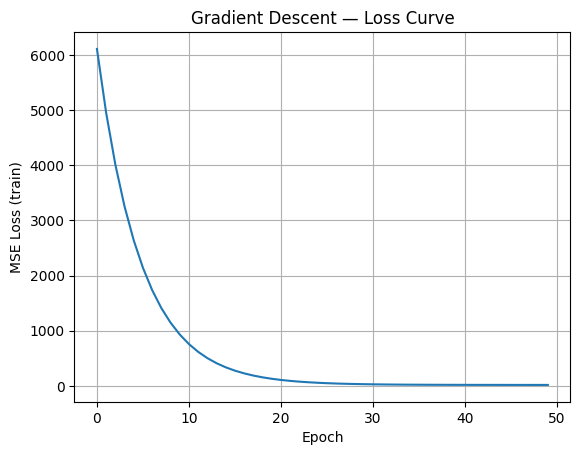

In [13]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (train)")
plt.title("Gradient Descent — Loss Curve")
plt.grid(True)
plt.show()


<h2 dir="rtl" style="line-height:200%;font-family:vazir;color:#0099cc;text-align:right;">
<font face="vazir" color="#0099cc">
ساخت جدول نهایی وزن‌ها و بایاس مدل
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در پایان با برگرداندن پارامترها به مقیاس اصلی، باید وزن‌ها و بایاس را در قالب یک دیتافریم مرتب ذخیره کنیم.  
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    اسم دیتافریم باید <code>params</code> باشد تا سامانه بتواند جواب شما را نمره دهی کند.
    <br>
    این دیتافریم شامل ۲ ستون با نام‌های <code>parameter</code> و <code>value</code> است.
    <br>
    هر سطر یک ویژگی (یا بایاس) و مقدار متناظر آن را نشان می‌دهد.
    <br>
     جدول زیر، ۷ سطر ابتدایی دیتافریم <code>params</code> را نشان می‌دهد.
    البته در جواب شما، اعداد ستون <code>value</code> ممکن است متفاوت باشد و این فقط یک مثال است.
    <br>
    <b>
    دقت کنید که مقادیر باید تا 4 رقم اعشار گرد شوند.
    </b>
</font>
</p>

<center>
<div dir=ltr style="direction: ltr;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

||<code>parameter</code>|<code>value</code>|
|:----:|:-------------------:|:------:|
|0|<code>hours_studied</code>|<code>3.4123</code>|
|1|<code>attendance_rate</code>|<code>1.2087</code>|
|2|<code>sleep_hours</code>|<code>0.8941</code>|
|3|<code>practice_questions</code>|<code>2.7654</code>|
|4|<code>distraction_hours</code>|<code>-0.6721</code>|
|5|<code>course_difficulty</code>|<code>-1.2934</code>|
|6|<code>bias</code>|<code>55.9832</code>|

</font>
</div>
</center>

In [14]:
params=pd.DataFrame({'parameter':feature_cols + ['bias'],'value':list(np.round(w_orig, 4)) + [round(b_orig, 4)]})

In [15]:
params

,parameter,value
0,hours_studied,5.9129
1,attendance_rate,17.6557
2,sleep_hours,1.9479
3,practice_questions,0.0916
4,distraction_hours,-2.9500
5,course_difficulty,-4.6275
6,bias,31.7305


<h1 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h1>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا در صورت نیاز به پشتیبانی امکان بررسی کد شما وجود داشته باشد.</font>
</p>

In [ ]:
print(df.columns)

Index(['hours_studied', 'attendance_rate', 'sleep_hours', 'practice_questions',
       'distraction_hours', 'course_difficulty', 'exam_score'],
      dtype='object')


In [17]:
import zlib
import zipfile

import os
if not os.path.exists(os.path.join(os.getcwd(), 'studying.ipynb')):
    %notebook -e studying.ipynb

params.to_csv("submission.csv", index=True)

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

file_names = ["studying.ipynb", "submission.csv"]
compress(file_names)

File Paths:
['studying.ipynb', 'submission.csv']
